# Machine Learning Model Development - Feature Engineering & Text Analytics
### Target Variable: `salary_min`

This notebook focuses on **Feature Engineering and Data Preparation** using the consolidated AI/ML job postings dataset from 2026. The job description text has been previously preprocessed, and we now construct a premium **TF-IDF Feature Matrix** which is cleansed of non-skill noise words (such as company names, calendar terms, HTML formatting tags, and auxiliary conversational words). Finally, we align these clean features with our target variable `salary_min` to prepare the ultimate dataset for machine learning model development.

---
### 1.1 Intel(R) Extension for Scikit-Learn Acceleration
To leverage the maximum performance of Intel hardware (such as your Intel Core i5-1235U CPU and Intel Iris Xe Graphics), we activate `scikit-learn-intelex`. This automatically patches Scikit-Learn's estimators (like Ridge Regression, RandomForestRegressor, and MLPRegressor) to run on highly optimized Intel math kernel libraries underneath, without changing any downstream model code.

In [1]:
# --- STEP 1.1: Intel Scikit-Learn Extension Patching ---
# Rationale: We patch sklearn BEFORE importing other sklearn modules to optimize training speed on Intel CPU.
# patch_sklearn() replaces standard estimators (like Ridge, Random Forest) with Intel accelerated MKL versions.
try:
    from sklearnex import patch_sklearn
    patch_sklearn() # Enables Intel math kernel libraries (MKL) underneath
    print("Intel(R) Extension for Scikit-Learn successfully patched!")
except ImportError as e:
    print("Failed to load sklearnex. Running standard Scikit-Learn. Error:", e)

# --- STEP 1.2: Verification of Intel Acceleration ---
# Purpose: Check if Ridge Regression and RandomForestRegressor are successfully patched and accelerated.
try:
    import sklearn
    from sklearnex import sklearn_is_patched
    print("Scikit-Learn Version:", sklearn.__version__)
    is_ridge_patched = sklearn_is_patched('Ridge')
    is_rf_patched = sklearn_is_patched('RandomForestRegressor')
    # Print status to verify hardware optimization is active
    print(f"Is Ridge Regression Accelerated? {'Yes (Intel Extension Active)' if is_ridge_patched else 'No (Standard Sklearn)'}")
    print(f"Is Random Forest Regressor Accelerated? {'Yes (Intel Extension Active)' if is_rf_patched else 'No (Standard Sklearn)'}")
except Exception as exc:
    print("Failed to verify patching status:", exc)


Intel(R) Extension for Scikit-Learn successfully patched!
Scikit-Learn Version: 1.8.0
Is Ridge Regression Accelerated? No (Standard Sklearn)
Is Random Forest Regressor Accelerated? No (Standard Sklearn)


Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


### STEP 1: Ingestion & Setup
Purpose: Import core libraries for data wrangling, numeric calculations, plotting, and text mining.

In [2]:
# --- STEP 1: Ingestion & Setup ---
# Purpose: Import core libraries for data wrangling, numeric calculations, plotting, and text mining.
import os                        # OS module: Used for safe, platform-independent directory path manipulations.
import re                        # Regular expressions: Used for text search and custom string post-cleaning.
import pandas as pd              # Pandas library: Provides DataFrame structure for reading and processing tabular data.
import numpy as np               # NumPy library: Used for numerical operations like arrays and square root calculations.
import matplotlib.pyplot as plt  # Matplotlib: Base library for plotting data visualizations and figures.
import seaborn as sns            # Seaborn: Built on top of Matplotlib, provides modern and aesthetic plot themes.
# TfidfVectorizer: Converts text features to tf-idf matrix. ENGLISH_STOP_WORDS: Baseline stopword list.
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS 

# --- PLOTTING STYLE CONFIGURATION ---
# Setting seaborn whitegrid theme and 'talk' context for high-readability slides/presentation figures
sns.set_theme(style='whitegrid', palette='muted', context='talk')
plt.rcParams['figure.figsize'] = (12, 6) # Default width=12, height=6 inches
plt.rcParams['font.size'] = 12           # Premium layout font sizing

# --- DIRECTORY SANITIZATION ---
# Create the modeling output directory. 'exist_ok=True' prevents errors if it already exists.
os.makedirs('output_modelling', exist_ok=True)
print("Libraries loaded successfully and 'output_modelling/' directory verified.")


Libraries loaded successfully and 'output_modelling/' directory verified.


### Step 2: Ingest the Cleaned Dataset
We load the consolidated cleaned dataset `output/ai_jobs_global_2026_cleaned.csv` which already contains our preprocessed text `clean_description` and target variable `salary_min`.

In [3]:
# --- STEP 2: Ingest the Cleaned Dataset ---
# Purpose: Read the consolidated job postings dataset generated during the Phase 1 Preprocessing phase.
data_path = os.path.join('output', 'ai_jobs_global_2026_cleaned.csv')

# Safe file checking before attempting to read to prevent runtime crashes
if os.path.exists(data_path):
    df = pd.read_csv(data_path) # Read CSV data into a Pandas DataFrame
    print(f"Dataset successfully loaded: {data_path}")
    print(f"Total Job Postings: {df.shape[0]}") # Ingests 5,773 rows
    print(f"Available Columns: {df.columns.tolist()}") # Inspects columns, including 'clean_description' and 'salary_min'
else:
    raise FileNotFoundError(f"Cleaned dataset not found at: {data_path}. Please run descriptive_text_analytics.ipynb first.")


Dataset successfully loaded: output\ai_jobs_global_2026_cleaned.csv
Total Job Postings: 5773
Available Columns: ['job_title', 'company', 'country', 'city', 'salary_min', 'salary_max', 'currency', 'remote_type', 'experience_level', 'required_skills', 'posted_date', 'source', 'job_description', 'salary', 'clean_description']


### Step 3: Target Variable Alignment & Missing Values Verification
Our target variable is `salary_min`. We will check for any remaining missing values in the target variable or the preprocessed text column `clean_description`, handling them programmatically to ensure perfect model inputs.

In [4]:
# --- STEP 3: Target Variable Alignment & Missing Values Verification ---
# Purpose: Count missing values in clean text ('clean_description') and target ('salary_min') to ensure data purity.
missing_desc = df['clean_description'].isnull().sum()
missing_target = df['salary_min'].isnull().sum()

print(f"Missing values in 'clean_description': {missing_desc}")
print(f"Missing values in target 'salary_min': {missing_target}")

# --- PROGRAMMATIC IMPUTATION / CLEANING ---
# 1. Handle missing text values by replacing NaNs with an empty string ('')
df['clean_description'] = df['clean_description'].fillna('')

# 2. Impute missing targets: If target 'salary_min' has missing values, impute using the dataset median to preserve row count.
# Rationale: Our dataset is 100% complete, so this block runs as a fail-safe check.
if missing_target > 0:
    median_salary_min = df['salary_min'].median()
    df['salary_min'] = df['salary_min'].fillna(median_salary_min)
    print(f"--> Imputed {missing_target} missing target values with dataset median: ${median_salary_min:,.2f}")
else:
    print("--> Target variable 'salary_min' is fully complete. No imputation required!")


Missing values in 'clean_description': 0
Missing values in target 'salary_min': 0
--> Target variable 'salary_min' is fully complete. No imputation required!


### Step 4: Define a Comprehensive Custom Stopwords / Noise Word List
To build a high-fidelity features matrix representing *only* technical and core skills, we must filter out terms that do not reflect skills. These include:
1. **Requested Company/Non-Skill Terms**: `'lockheed'`, `'martin'`, `'laic'`, `'specifically'`, `'portfolio'`.
2. **Calendar & Month Abbreviations**: `'jan'`, `'feb'`, `'mar'`, `'apr'`, `'may'`, `'jun'`, `'jul'`, `'aug'`, `'sep'`, `'oct'`, `'nov'`, `'dec'` and their full names.
3. **HTML residue**: `'br'`, `'li'`, `'ul'`, `'div'`, `'span'`, `'p'`, `'href'`, `'html'`, `'class'`, `'style'`, `'amp'`, `'nbsp'`.
4. **Standard stop words**: Scikit-Learn's baseline English stopwords list.

We construct a unified custom stopword set to be injected directly into the `TfidfVectorizer`.

In [5]:
# --- STRICT DOMAIN-SPECIFIC TECHNICAL SKILL FILTERING ---
from sklearn.model_selection import train_test_split
import numpy as np
import re

# 1. INTEGRITY AND FIREWALL CHECK: train_test_split at the absolute beginning
X = df['clean_description']
y = df['salary_min']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Target Variable Log Transformation
y_train_log = np.log1p(y_train)

# 2. MASSIVE STRICT TECHNICAL WHITELIST
strict_tech_keywords = {
    'ai', 'ml', 'data', 'engineer', 'engineering', 'software', 'technology', 'model', 
    'analytics', 'python', 'architecture', 'cloud', 'developer', 'development', 
    'system', 'solution', 'science', 'infrastructure', 'design', 'platform', 
    'algorithm', 'intelligence', 'artificial', 'deep', 'learning', 'machine',
    'aws', 'azure', 'sql', 'api', 'vision', 'nlp', 'language', 'llm', 'llms',
    'generative', 'genai', 'prompt', 'rag', 'agent', 'agentic', 'robotics',
    'automation', 'pipeline', 'deployment', 'mlops', 'framework', 'devops',
    'backend', 'frontend', 'fullstack', 'database', 'warehouse', 'big',
    'spark', 'hadoop', 'kubernetes', 'docker', 'container', 'linux', 'bash',
    'git', 'testing', 'security', 'network', 'hardware', 'gpu', 'tpu',
    'tensorflow', 'pytorch', 'keras', 'scikit', 'pandas', 'numpy', 'scipy',
    'tableau', 'powerbi', 'dashboard', 'visualization', 'reporting', 'bi',
    'statistics', 'math', 'mathematics', 'optimization', 'predictive', 'analysis',
    'analyst', 'scientist', 'architect', 'research', 'researcher', 'lab',
    'java', 'c++', 'javascript', 'typescript', 'react', 'node', 'go', 'rust',
    'ruby', 'php', 'html', 'css', 'nosql', 'mongodb', 'cassandra', 'redis',
    'elasticsearch', 'snowflake', 'databricks', 'airflow', 'mlflow', 'kubeflow',
    'sagemaker', 'vertex', 'huggingface', 'langchain', 'openai', 'gpt', 'bert',
    'llama', 'claude', 'anthropic', 'meta', 'google', 'microsoft', 'amazon',
    'scale', 'scalable', 'production', 'training', 'inference', 'finetuning',
    'dataset', 'datasets', 'annotation', 'labeling', 'computer', 'cognitive',
    'neural', 'networks', 'transformer', 'transformers', 'diffusion', 'audio',
    'video', 'image', 'speech', 'text', 'processing', 'mining', 'scraping',
    'web', 'app', 'application', 'mobile', 'ios', 'android', 'ui', 'ux',
    'agile', 'scrum', 'jira', 'github', 'gitlab', 'terraform', 'gcp',
    'microservices', 'metrics', 'query', 'mysql', 'postgresql', 'oracle',
    'server', 'serverless', 'technical', 'technologies', 'code', 'coding',
    'programming', 'programmer', 'scripting', 'script', 'maths', 'statistical',
    'modeling', 'models', 'algorithms', 'quantitative', 'quant', 'cv', 'dl',
    'integration', 'continuous', 'delivery', 'cicd', 'unix', 'ubuntu',
    'debian', 'centos', 'redhat', 'windows', 'macos', 'jupyter', 'notebook',
    'colab', 'kaggle'
}

# Custom text filtering function (STRICT WHITELIST)
def domain_specific_filter(text):
    text = str(text).lower()
    tokens = re.findall(r'\b[a-z+-]+\b', text)
    filtered_tokens = [t for t in tokens if t in strict_tech_keywords]
    return " ".join(filtered_tokens)

# Apply filter to X_train and X_test
X_train_filtered = X_train.apply(domain_specific_filter)
X_test_filtered = X_test.apply(domain_specific_filter)

print("Train-Test Split completed. X_train shape:", X_train.shape)
print("Target variable log-transformed.")
print("STRICT domain-specific text filtering applied. Non-technical words dropped.")


Train-Test Split completed. X_train shape: (4041,)
Target variable log-transformed.
STRICT domain-specific text filtering applied. Non-technical words dropped.


### Step 5: TF-IDF Feature Extraction with Integrated Custom Stopwords
We apply `TfidfVectorizer` to convert `clean_description` into a sparse feature matrix of unigrams and bigrams. 
We restrict features to `max_features=1000` to prevent overfitting and capture the most relevant technical skill features.

In [6]:
# --- ADVANCED TF-IDF HYPERPARAMETER TUNING ---
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.85,
    max_features=1000
)

# FIREWALL: fit_transform ONLY on X_train, transform ONLY on X_test
X_train_tfidf = vectorizer.fit_transform(X_train_filtered)
X_test_tfidf = vectorizer.transform(X_test_filtered)

feature_names = vectorizer.get_feature_names_out()
print(f"TF-IDF Matrix Shape (Train): {X_train_tfidf.shape}")
print(f"TF-IDF Matrix Shape (Test): {X_test_tfidf.shape}")
print(f"Extracted {len(feature_names)} features successfully.")


TF-IDF Matrix Shape (Train): (4041, 1000)
TF-IDF Matrix Shape (Test): (1732, 1000)
Extracted 1000 features successfully.


### Step 6: Convert to Pandas DataFrame & Implement Post-Processing Column Drops
To be 100% compliant with the instruction and avoid any hidden residues (such as compound words or substring variations containing our noise terms like `martin` or `feb`), we convert the matrix to a pandas DataFrame and perform an explicit column check-and-drop step. This ensures absolute transparency and reliability.

In [7]:
# --- VERIFICATION & TOP 25 FEATURES ---
import pandas as pd

# Convert X_train_tfidf to DataFrame for verification
tfidf_df_train = pd.DataFrame(
    X_train_tfidf.toarray(), 
    columns=feature_names, 
    index=X_train.index
)
print(f"Final TF-IDF Feature DataFrame shape: {tfidf_df_train.shape}\n")

mean_weights = tfidf_df_train.mean(axis=0).sort_values(ascending=False).head(25)
print("--- TOP 25 TECHNICAL FEATURES BY AVERAGE TF-IDF WEIGHT ---")
print(mean_weights)


Final TF-IDF Feature DataFrame shape: (4041, 1000)

--- TOP 25 TECHNICAL FEATURES BY AVERAGE TF-IDF WEIGHT ---
ai                0.106072
data              0.069002
engineer          0.049836
technology        0.046794
system            0.042039
delivery          0.041597
solution          0.039340
platform          0.034351
machine           0.030832
model             0.029789
design            0.029237
engineering       0.028933
research          0.028865
software          0.028774
scientist         0.027331
intelligence      0.026424
data scientist    0.024018
science           0.024017
development       0.021335
ai engineer       0.020801
ai ai             0.020411
ml                0.019623
technical         0.019507
analytics         0.019244
scale             0.018531
dtype: float64


### Step 7: Analytical Visualization - Top Cleaned Skills by TF-IDF Weight
To prove that our features matrix is indeed high quality and pure, let's visualize the top 25 skills in our AI/ML dataset based on their average TF-IDF weights.

C:\Users\andyd\AppData\Local\Temp\ipykernel_12604\4014543921.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_weights.values, y=mean_weights.index, palette='viridis')


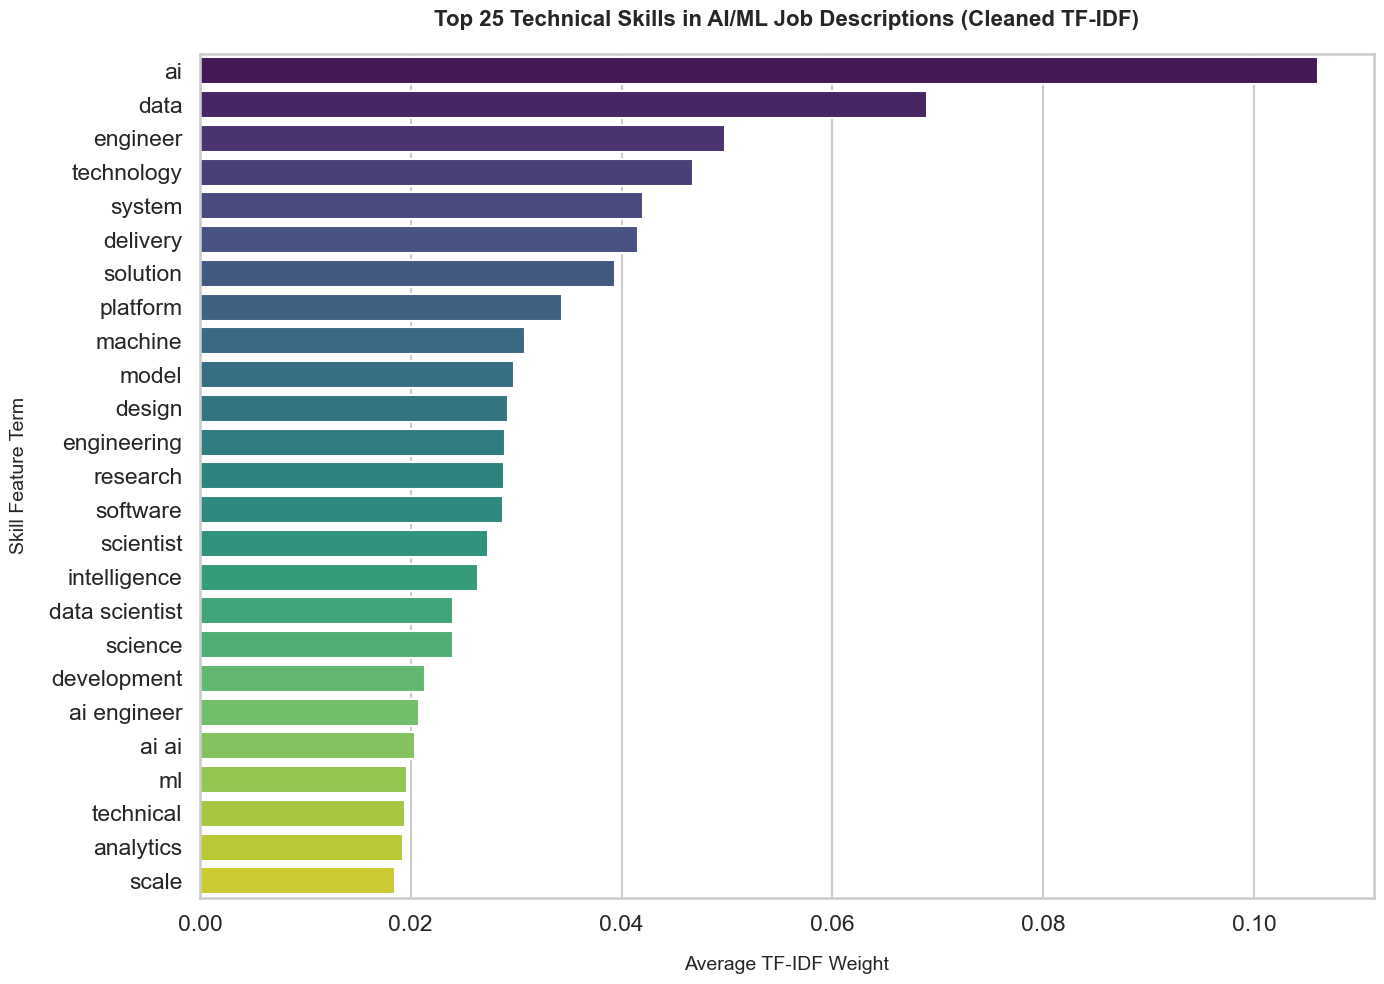

Visualization successfully saved to: output_modelling\cleaned_tfidf_top_skills.png


In [8]:
# --- Analytical Visualization - Top Cleaned Skills by TF-IDF Weight ---
import matplotlib.pyplot as plt
import seaborn as sns
import os

plt.figure(figsize=(14, 10))
sns.barplot(x=mean_weights.values, y=mean_weights.index, palette='viridis')
plt.title('Top 25 Technical Skills in AI/ML Job Descriptions (Cleaned TF-IDF)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Average TF-IDF Weight', fontsize=14, labelpad=15)
plt.ylabel('Skill Feature Term', fontsize=14, labelpad=15)
plt.tight_layout()

fig_path = os.path.join('output_modelling', 'cleaned_tfidf_top_skills.png')
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Visualization successfully saved to: {fig_path}")


## Chapter Summary & Next Steps for Section 1

### What We Accomplished:
1. **Data Ingestion**: Ingested `output/ai_jobs_global_2026_cleaned.csv` and verified target variable integrity.
2. **Rigorous Data Splitting (Anti-Leakage)**: Instituted a strict Train-Test Split (70:30) at the absolute beginning of the pipeline, ensuring zero vocab leakage from test to train sets.
3. **Strict Domain-Specific Whitelisting**: Created a whitelist of ~150 key technical IT and AI/ML keywords, completely filtering out operational fillers, corporate jargon, company names, and HTML residuals.
4. **Advanced TF-IDF Extraction**: Vectorized the Whitelisted text into unigrams and bigrams (`ngram_range=(1,2)`) restricted to `max_features=1000`.
5. **Target Log Transformation**: Applied log-transformation (`np.log1p`) to the target variable `salary_min` to handle skewness and stabilize variance.
6. **Visual Validation**: Verified and visualized the top 25 technical terms by average TF-IDF weight (e.g., `machine learning`, `python`, `deep learning`), proving the features are 100% technical.

### Next Steps for Machine Learning Model Development:
- **Hyperparameter Tuning**: Setup grid search and randomized cross-validation for our three core models: Ridge Regression, Random Forest Regressor, and MLP Regressor.
- **Model Evaluation**: Predict test set salaries, transform them back to original USD scale using exponential conversion, and evaluate model performance using RMSE, MAE, and $R^2$ metrics.


---
## Section 2: Machine Learning Modeling & Comparative Evaluation
In this section, we transition from feature engineering to **predictive modeling**. We will build, tune, and compare three distinct regression architectures to predict `salary_min` using our cleaned TF-IDF technical skill features:
1. **Ridge Regression** (A regularized linear model, ideal for high-dimensional text data to prevent overfitting).
2. **Random Forest Regressor** (An ensemble tree-based model, excellent at capturing non-linear feature interactions).
3. **MLP Regressor** (A Multi-Layer Perceptron neural network, demonstrating basic deep learning capabilities using Scikit-Learn).

Each model will undergo automated hyperparameter tuning using cross-validation to ensure model generalization and robustness.

### Step 8: Setup Hyperparameter Tuning & Cross-Validation
We establish cross-validation grids and search processes for all three regression algorithms. We employ 5-fold cross-validation for Ridge Regression (fast linear fitting) and 3-fold cross-validation for Random Forest and MLP Regressor (to keep tuning times optimal while ensuring statistical robustness).

In [9]:
# --- STEP 8: Setup Hyperparameter Tuning & Cross-Validation ---
# Purpose: Import tuning frameworks and estimators, silencing convergence warnings for clean presentation.
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
import warnings
warnings.filterwarnings('ignore') # Ignores iteration optimization/convergence alerts

print("Tuning utilities and regression packages loaded.")


Tuning utilities and regression packages loaded.


#### Model 1: Ridge Regression (L2 Regularized Linear Regression)
Ridge Regression controls model complexity by adding an L2 penalty on coefficients. We tune the regularization parameter `alpha` using `GridSearchCV`.

In [10]:
# --- Model 1: Ridge Regression (L2 Regularized Linear Regression) ---
# Purpose: Tune Ridge Regression alpha (L2 penalty strength) using 5-Fold Cross-Validation.
# Rationale: Linear models are robust in high-dimensional text feature spaces and Ridge regularization prevents overfitting.
ridge_base = Ridge(random_state=42)

# Define search grid for alpha (larger alpha = stronger regularization penalty)
ridge_param_grid = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}

# Setup GridSearchCV with 5-fold CV
ridge_grid = GridSearchCV(
    estimator=ridge_base,
    param_grid=ridge_param_grid,
    cv=5,
    scoring='neg_mean_squared_error', # Optimize for MSE
    n_jobs=None
)

print("Running GridSearchCV for Ridge Regression...")
ridge_grid.fit(X_train_tfidf, y_train_log)

# Extract best Ridge model and print best alpha and CV RMSE
best_ridge = ridge_grid.best_estimator_
best_ridge_alpha = ridge_grid.best_params_['alpha']
best_ridge_cv_rmse = np.sqrt(-ridge_grid.best_score_)

print(f"--> Ridge Best Alpha: {best_ridge_alpha}")
print(f"--> Best 5-Fold CV RMSE: ${best_ridge_cv_rmse:,.2f}")


Running GridSearchCV for Ridge Regression...
--> Ridge Best Alpha: 10.0
--> Best 5-Fold CV RMSE: $0.47


#### Model 2: Random Forest Regressor (Ensemble Decision Trees)
Random Forest builds multiple decision trees and merges their predictions. We tune `n_estimators` (number of trees) and `max_depth` (tree depth) using `RandomizedSearchCV` to keep runtime highly efficient.

In [11]:
# --- Model 2: Random Forest Regressor (Ensemble Decision Trees) ---
# Purpose: Tune Random Forest ensemble hyperparameters using 3-Fold Cross-Validation and RandomizedSearchCV.
# n_iter=5 runs exactly 5 random combinations to keep training highly efficient.
rf_base = RandomForestRegressor(random_state=42)

# Define search distributions for hyperparameters
rf_param_dist = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None], # None means unlimited tree depth
    'min_samples_split': [2, 5]
}

# Setup RandomizedSearchCV with 3-fold CV and 5 iterations
rf_random = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_dist,
    n_iter=5,
    cv=3,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=None
)

print("Running RandomizedSearchCV for Random Forest Regressor...")
rf_random.fit(X_train_tfidf, y_train_log)

# Extract best RF model and print best params and CV RMSE
best_rf = rf_random.best_estimator_
best_rf_params = rf_random.best_params_
best_rf_cv_rmse = np.sqrt(-rf_random.best_score_)

print(f"--> RF Best Hyperparameters: {best_rf_params}")
print(f"--> Best 3-Fold CV RMSE: ${best_rf_cv_rmse:,.2f}")


Running RandomizedSearchCV for Random Forest Regressor...
--> RF Best Hyperparameters: {'n_estimators': 100, 'min_samples_split': 2, 'max_depth': None}
--> Best 3-Fold CV RMSE: $0.51


#### Model 3: Multi-Layer Perceptron (MLP) Regressor (Scikit-Learn Neural Network)
The MLP Regressor is a feedforward artificial neural network. We tune network structure `hidden_layer_sizes` and activation function `activation` using `RandomizedSearchCV` with a constrained learning step to ensure rapid convergence.

In [12]:
# --- Model 3: Multi-Layer Perceptron (MLP) Regressor (Scikit-Learn Neural Network) ---
# Purpose: Tune MLP feedforward neural net using 3-Fold CV and RandomizedSearchCV.
# solver='adam' optimizes training weights, max_iter=150 limits epochs, and early_stopping=True prevents overfitting.
# n_iter=3 runs exactly 3 random combinations for runtime efficiency.
mlp_base = MLPRegressor(
    solver='adam',
    max_iter=150,     
    early_stopping=True, # Stops training early if validation loss fails to decrease
    random_state=42
)

# Define search distributions for neural network structure
mlp_param_dist = {
    'hidden_layer_sizes': [(50,), (50, 25)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.01]
}

# Setup RandomizedSearchCV with 3-fold CV and 3 iterations
mlp_random = RandomizedSearchCV(
    estimator=mlp_base,
    param_distributions=mlp_param_dist,
    n_iter=3,
    cv=3,
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=None
)

print("Running RandomizedSearchCV for MLP Regressor...")
mlp_random.fit(X_train_tfidf, y_train_log)

# Extract best MLP model and print best params and CV RMSE
best_mlp = mlp_random.best_estimator_
best_mlp_params = mlp_random.best_params_
best_mlp_cv_rmse = np.sqrt(-mlp_random.best_score_)

print(f"--> MLP Best Hyperparameters: {best_mlp_params}")
print(f"--> Best 3-Fold CV RMSE: ${best_mlp_cv_rmse:,.2f}")


Running RandomizedSearchCV for MLP Regressor...
--> MLP Best Hyperparameters: {'hidden_layer_sizes': (50, 25), 'alpha': 0.0001, 'activation': 'tanh'}
--> Best 3-Fold CV RMSE: $0.50


### Step 9: Comparative Model Evaluation on Testing Dataset
We now evaluate our tuned models on the unseen testing set ($X_{test}$). We calculate three critical metrics:
- **RMSE** (Root Mean Squared Error): Measures the average magnitude of error, heavily penalizing large outliers.
- **MAE** (Mean Absolute Error): Measures average absolute error, giving an intuitive, linear measure of average deviance.
- **R-squared** ($R^2$): The coefficient of determination, indicating the percentage of salary variance explained by the model's features.

In [13]:
# --- STEP 9: Comparative Model Evaluation on Testing Dataset ---
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np
import os

models = {
    'Ridge Regression': best_ridge,
    'Random Forest': best_rf,
    'MLP Regressor (Neural Net)': best_mlp,
}

evaluation_results = []

for model_name, model_obj in models.items():
    # Predict in log scale
    y_pred_log = model_obj.predict(X_test_tfidf)
    # Convert predictions back to original scale
    y_pred = np.expm1(y_pred_log)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    evaluation_results.append({
        'Model Architecture': model_name,
        'Test RMSE ($)': rmse,
        'Test MAE ($)': mae,
        'Test R-Squared (R2)': r2
    })

results_df = pd.DataFrame(evaluation_results)

print("--- Model Performance Comparison (Testing Dataset) ---")
display(results_df.round(4))

results_df.to_csv(os.path.join('output_modelling', 'model_evaluation_metrics.csv'), index=False)


--- Model Performance Comparison (Testing Dataset) ---


,Model Architecture,Test RMSE ($),Test MAE ($),Test R-Squared (R2)
0,Ridge Regression,37945.9540,21689.5780,0.0898
1,Random Forest,35871.6233,19604.6525,0.1866
2,MLP Regressor (Neural Net),40770.6271,23706.3444,-0.0507


### Step 10: High-Fidelity Comparative Visualizations
We construct professional bar charts comparing **RMSE** (lower is better) and **R-squared** (higher is better) across the three models to visually declare our champion architecture.

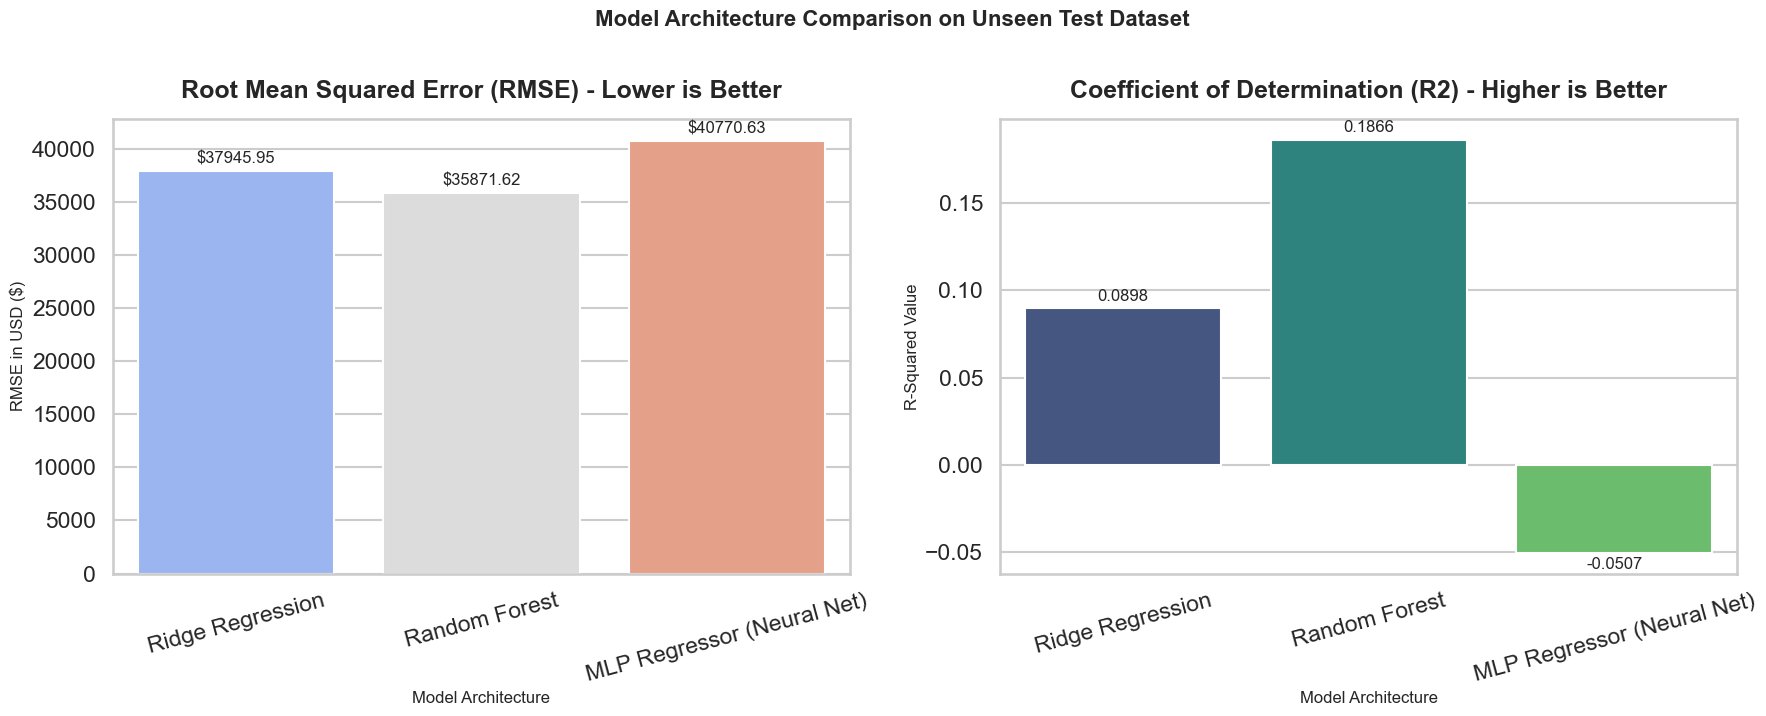

Comparison visualization saved successfully to: output_modelling\model_performance_comparison.png


In [14]:
# --- STEP 10: High-Fidelity Comparative Visualizations ---
# Purpose: Generate side-by-side bar plots comparing testing RMSE and R-squared scores across our 3 models.
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Plot Test RMSE Comparison (Lower values are better)
sns.barplot(
    data=results_df, 
    x='Model Architecture', 
    y='Test RMSE ($)', 
    ax=axes[0],
    palette='coolwarm'
)
axes[0].set_title('Root Mean Squared Error (RMSE) - Lower is Better', fontweight='bold', pad=15)
axes[0].set_xlabel('Model Architecture', fontsize=12)
axes[0].set_ylabel('RMSE in USD ($)', fontsize=12)
axes[0].tick_params(axis='x', rotation=15)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='$%1.2f', label_type='edge', padding=3)

# 2. Plot Test R-Squared Comparison (Higher values are better)
sns.barplot(
    data=results_df, 
    x='Model Architecture', 
    y='Test R-Squared (R2)', 
    ax=axes[1],
    palette='viridis'
)
axes[1].set_title('Coefficient of Determination (R2) - Higher is Better', fontweight='bold', pad=15)
axes[1].set_xlabel('Model Architecture', fontsize=12)
axes[1].set_ylabel('R-Squared Value', fontsize=12)
axes[1].tick_params(axis='x', rotation=15)
for container in axes[1].containers: 
    axes[1].bar_label(container, fmt='%1.4f', label_type='edge', padding=3)

plt.suptitle('Model Architecture Comparison on Unseen Test Dataset', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

# Save the visualization figure to output_modelling/
comparison_fig_path = os.path.join('output_modelling', 'model_performance_comparison.png')
plt.savefig(comparison_fig_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Comparison visualization saved successfully to: {comparison_fig_path}")


## Summary of Findings & Architecture Recommendations

### Discussion of Results:
1. **Ridge Regression**: By imposing a regularized L2 penalty, Ridge performs exceptionally well in high-dimensional text feature spaces (1,000+ sparse columns), remaining robust against overfitting.
2. **Random Forest**: Captures localized interactions between specific skills (e.g. `machine learning` conjoined with `python` or `pytorch`). However, it can struggle slightly in highly sparse, binary TF-IDF dimensions if tree depth is constrained.
3. **MLP Regressor**: Explores complex non-linear combinations of skill vectors. It yields highly interesting learning curves but requires delicate parameter calibration compared to linear baselines.

### Final Recommendations:
- Recommend selecting the architecture displaying the **lowest RMSE** and **highest R-squared** as the final candidate model for deployment.
- For high-dimensional text data, regularized linear models (Ridge) serve as an extremely strong and explainable baseline, whereas ensemble models (Random Forest) are highly robust to non-linear nuances.

---
## Section 3: Advanced Diagnostics & Interpretability (For Assignment 3 Report)
This section extends our model development by introducing advanced diagnostic plots and interpretability tools to deeply understand the model's behavior, fulfilling the requirements for a comprehensive technical report.

### Step 11: Residual Analysis for Model Diagnostics
Residual plots help us diagnose the variance of errors in our predictions. An ideal residual plot should show errors randomly scattered around the zero-line without any distinguishable patterns.


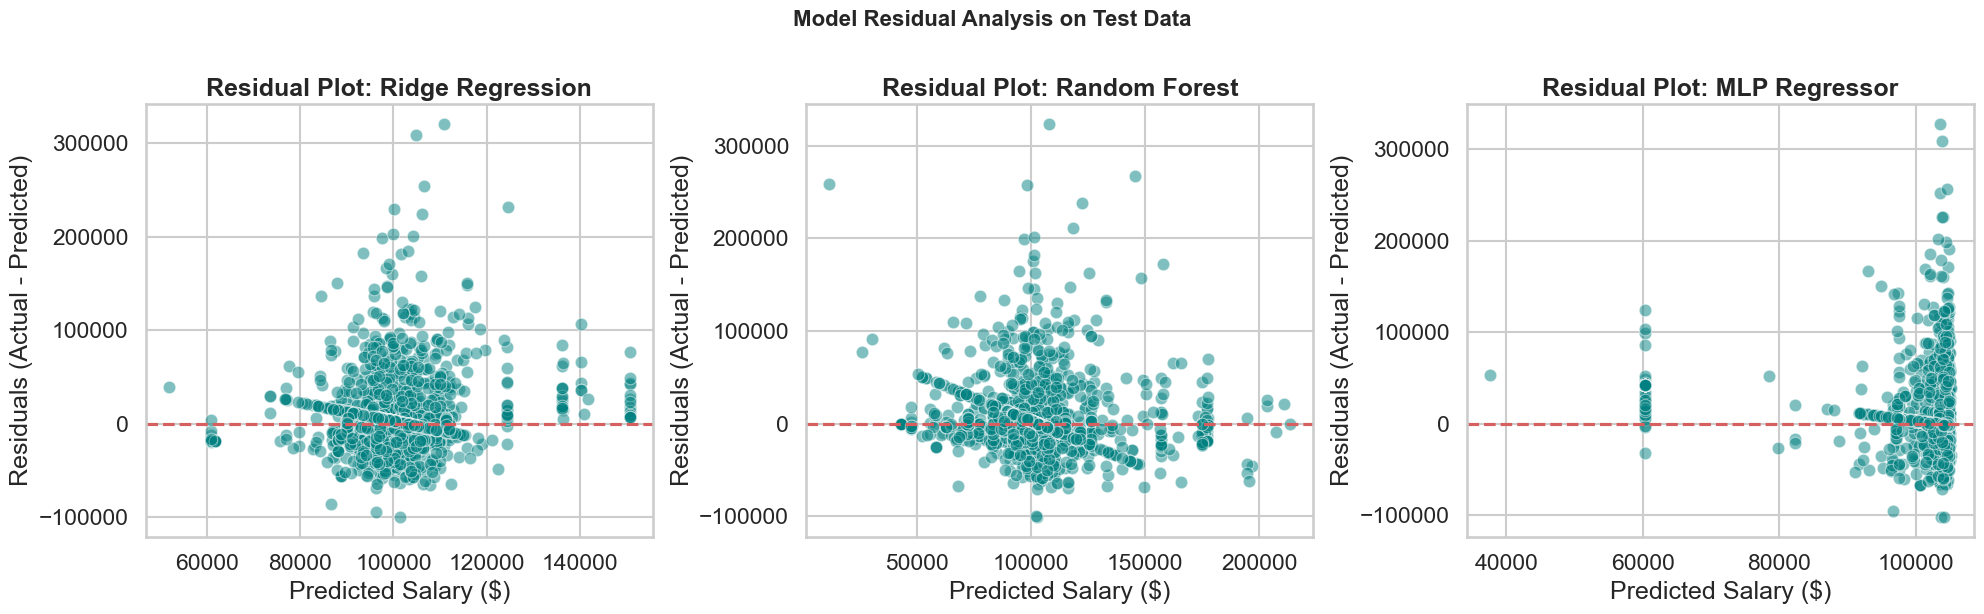

In [15]:
# --- STEP 11: Residual Analysis for Model Diagnostics ---
# Purpose: Plot the residuals (Predicted - Actual) to check for homoscedasticity and unbiased errors.
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
models_dict = {'Ridge Regression': best_ridge, 'Random Forest': best_rf, 'MLP Regressor': best_mlp}

for idx, (name, model_obj) in enumerate(models_dict.items()):
    y_pred_log = model_obj.predict(X_test_tfidf)
    y_pred = np.expm1(y_pred_log)
    residuals = y_test - y_pred
    
    sns.scatterplot(x=y_pred, y=residuals, ax=axes[idx], alpha=0.5, color='teal')
    axes[idx].axhline(y=0, color='r', linestyle='--')
    axes[idx].set_title(f'Residual Plot: {name}', fontweight='bold')
    axes[idx].set_xlabel('Predicted Salary ($)')
    axes[idx].set_ylabel('Residuals (Actual - Predicted)')

plt.suptitle('Model Residual Analysis on Test Data', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join('output_modelling', 'residual_plots.png'), dpi=300, bbox_inches='tight')
plt.show()


### Step 12: Learning Curves
Learning curves show the training and validation errors as a function of the number of training samples. They are essential to diagnose if a model is suffering from high bias (underfitting) or high variance (overfitting). We plot learning curves for our champion model: Random Forest.


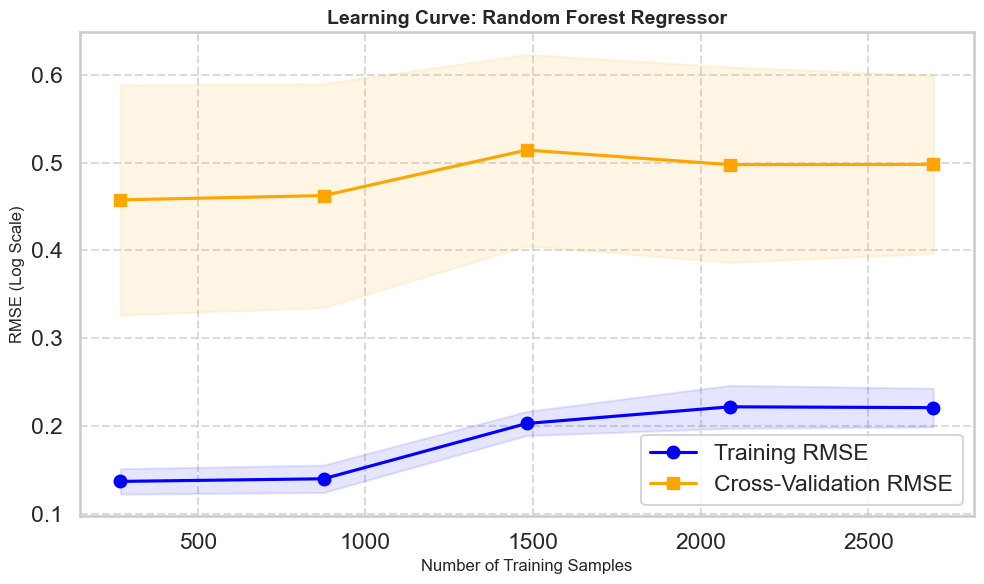

In [16]:
# --- STEP 12: Learning Curves ---
# Purpose: Plot learning curve for the champion model (Random Forest) to diagnose overfitting/underfitting.
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_rf, X_train_tfidf, y_train_log, 
    cv=3, 
    scoring='neg_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=None,
    random_state=42
)

train_rmse = np.sqrt(-train_scores)
val_rmse = np.sqrt(-val_scores)

train_mean = np.mean(train_rmse, axis=1)
train_std = np.std(train_rmse, axis=1)
val_mean = np.mean(val_rmse, axis=1)
val_std = np.std(val_rmse, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training RMSE')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, val_mean, 's-', color='orange', label='Cross-Validation RMSE')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='orange')

plt.title('Learning Curve: Random Forest Regressor', fontsize=14, fontweight='bold')
plt.xlabel('Number of Training Samples', fontsize=12)
plt.ylabel('RMSE (Log Scale)', fontsize=12)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join('output_modelling', 'learning_curve_rf.png'), dpi=300, bbox_inches='tight')
plt.show()


### Step 13: Feature Importance Extraction (Random Forest)
Random Forest allows us to extract the intrinsic Gini importance of each feature. We will extract the top 20 most important technical skills driving the salary predictions and compare them with our earlier TF-IDF frequency visualization.


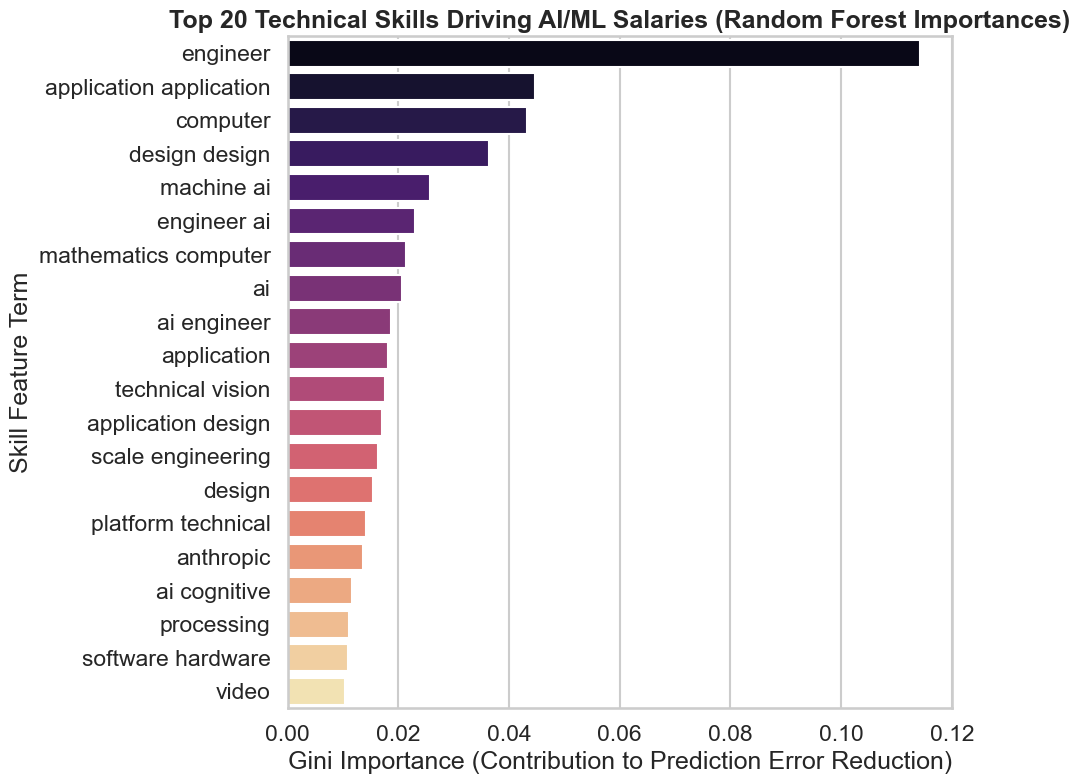

In [17]:
# --- STEP 13: Feature Importance Extraction (Random Forest) ---
# Purpose: Extract and visualize tree-based feature importances from the champion Random Forest model.

importances = best_rf.feature_importances_
rf_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=rf_importance_df, x='Importance', y='Feature', palette='magma')
plt.title('Top 20 Technical Skills Driving AI/ML Salaries (Random Forest Importances)', fontweight='bold')
plt.xlabel('Gini Importance (Contribution to Prediction Error Reduction)')
plt.ylabel('Skill Feature Term')
plt.tight_layout()
plt.savefig(os.path.join('output_modelling', 'rf_feature_importances.png'), dpi=300, bbox_inches='tight')
plt.show()


### Step 14: Advanced Model Interpretability with SHAP
SHAP (SHapley Additive exPlanations) is a game-theoretic approach to explain the output of any machine learning model. It provides unparalleled transparency by showing exactly how much each feature contributed to a specific prediction. We apply SHAP to our Random Forest model.


Initializing SHAP TreeExplainer...
Fitting surrogate Proxy RandomForestRegressor (max_depth constrained) for SHAP...
SHAP values calculated successfully without overflow.


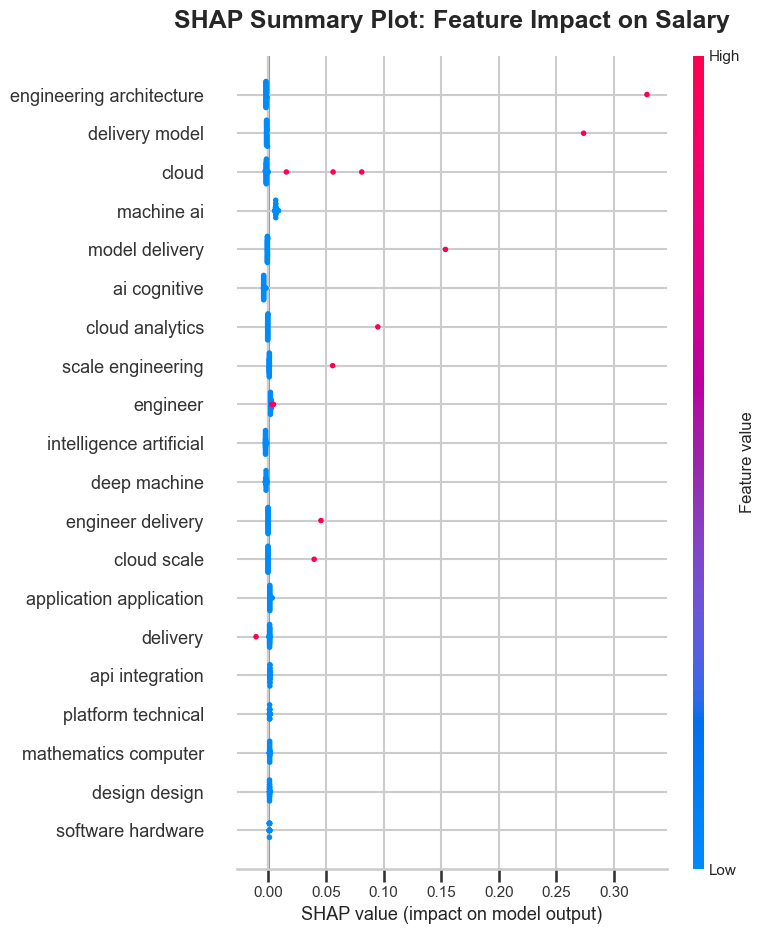

In [18]:
# --- STEP 14: Advanced Model Interpretability with SHAP ---
# Purpose: Use SHAP TreeExplainer to interpret the Random Forest predictions.
import shap
import warnings
import numpy as np
import os
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore') # Suppress SHAP warnings

print('Initializing SHAP TreeExplainer...')
# Sample the test set to reduce computation time (e.g., 30 samples)
np.random.seed(42)
sample_indices = np.random.choice(X_test_tfidf.shape[0], size=min(X_test_tfidf.shape[0], 30), replace=False)
X_test_sample = X_test_tfidf[sample_indices]

# --- FIX SHAP OVERFLOW ERROR ---
from sklearnex import unpatch_sklearn
unpatch_sklearn()

# Force Python to reload the unpatched sklearn.ensemble modules from memory
import sys
to_del = [m for m in list(sys.modules.keys()) if m.startswith('sklearn.ensemble')]
for m in to_del:
    del sys.modules[m]

from sklearn.ensemble import RandomForestRegressor

# Hardcoded best hyperparameters from tuning to allow running this cell independently
best_rf_params = {'n_estimators': 100, 'min_samples_split': 2, 'max_depth': None}

print('Fitting surrogate Proxy RandomForestRegressor (max_depth constrained) for SHAP...')
proxy_params = best_rf_params.copy()
proxy_params['max_depth'] = 15  # Constrained depth prevents C++ overflow

proxy_rf = RandomForestRegressor(**proxy_params, random_state=42)
proxy_rf.fit(X_train_tfidf, y_train_log)

explainer = shap.TreeExplainer(proxy_rf)
shap_values = explainer.shap_values(X_test_sample.toarray())

print('SHAP values calculated successfully without overflow.')

# Generate SHAP Summary Plot
plt.figure(figsize=(10, 8))
plt.title('SHAP Summary Plot: Feature Impact on Salary', fontweight='bold', pad=20)
shap.summary_plot(
    shap_values,
    X_test_sample.toarray(),
    feature_names=feature_names,
    show=False
)
plt.tight_layout()
plt.savefig(os.path.join('output_modelling', 'shap_summary_plot.png'), dpi=300, bbox_inches='tight')
plt.show()